<a href="https://colab.research.google.com/github/KeerthanaSistla/Sem6DeepLearning/blob/main/deeplearningsem6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction

Features of Deep Learning
*   Requires More amount of data
*   DL deals with non linear-data
*   Images, videos, audio and text
*   Complex model (hard to interpret)
*   Requires Graphical and Tenser Processing Units
*   Takes large computation
*   Automatic feature extractuion

PyTourch
*   Implimented  using LUA

TensorFlow
*   Implimented using C++, CUDA or Python

Keras
*   Implimented using Python

#Basic Coding

In [ ]:
import tensorflow as tf


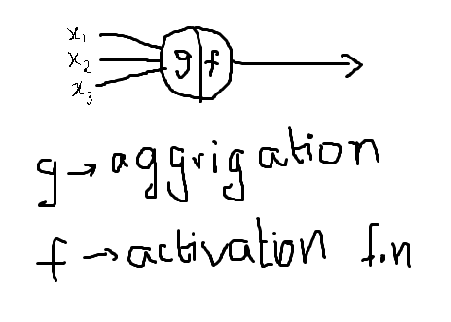

**g (aggrigation)** adds i.e., x1 + x2 + x3

**f (activation)** checks with condition
*   Step f.n, Sigmoid f.n, etc.
*   Fired if output is tangable

**Weights**
*   Priority of each input
*   g = x1w1 + x2w2 + x3w3

**Bias**
*   Adds non-linearity
*   Acts as a decision boundry

#Week 2

In [ ]:
import numpy as np

def step(x):
  return 1 if x >= 0 else 0

class Perceptron:
  def __init__(self, weights, bias):
    self.weights = weights
    self.bias = bias

  def predict(self, inputs):
              z = np.dot(self.weights, inputs)+self.bias
              return step(z)

#AND Operation
weights = np.array([1, 1])
bias = -1.5

and_gate = Perceptron(weights, bias)

print("AND Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", and_gate.predict(np.array(x)))

#OR Operation
weights = np.array([1, 1])
bias = -0.5

or_gate = Perceptron(weights, bias)

print("OR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", or_gate.predict(np.array(x)))

AND Gate
(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1
OR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1


In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_network:
    def __init__(self):
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        self.w_out = np.array([1, -2])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)
        h2 = step(np.dot(self.w_and, x) + self.b_and)
        output = step(np.dot(self.w_out, [h1, h2]) + self.b_out)
        return output

xor = XOR_network()

print("XOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor.predict(np.array(x)))

XOR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


In [ ]:
# ~XOR Function

import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_network:
    def __init__(self):
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        self.w_out = np.array([1, -2])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)
        h2 = step(np.dot(self.w_and, x) + self.b_and)
        return step(np.dot(self.w_out, [h1, h2]) + self.b_out)

class XNOR_network(XOR_network):
    def predict(self, x):
        return 1 - super().predict(x)

xnor = XNOR_network()

print("XNOR Gate")
for x in [(0,0),(0,1),(1,0),(1,1)]:
    print(x, "->", xnor.predict(np.array(x)))

XNOR Gate
(0, 0) -> 1
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


In [ ]:
# Harsh Threshold
import numpy as np

def step(x):
  return 1 if x >= 0 else 0

class Neuron:
  def __init__(self, weights, bias):
    self.weights = weights
    self.bias = bias
  def feedforward(self, inputs):
    total = np.dot(self.weights, inputs) + self.bias
    return step(total)

weights = np.array([0, 1])
b_1 = -3.1
b_2 = 2
b_3 = -3.0

n = Neuron(weights, b_1)
n_2 = Neuron(weights, b_2)
n_3 = Neuron(weights,b_3)

x = np.array([2, 3])

print("with bias -3.1:",n.feedforward(x))
print("\nwith bias -3.0:",n_3.feedforward(x))
print("\nwith bias 2:",n_2.feedforward(x))

with bias -3.1: 0

with bias -3.0: 1

with bias 2: 1


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("movies.csv")

X = data[['f1', 'f2', 'f3', 'f4']].values
y = data['label'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

learning_rate = 0.01
epochs = 50
weights = np.zeros(X.shape[1])
bias = 0.0

def step_function(z):
    return 1 if z >= 0 else 0

for epoch in range(epochs):
    total_errors = 0

    indices = np.random.permutation(len(X))

    for i in indices:
        linear_output = np.dot(X[i], weights) + bias
        y_pred = step_function(linear_output)

        error = y[i] - y_pred

        if error != 0:
            weights += learning_rate * error * X[i]
            bias += learning_rate * error
            total_errors += 1

    print(
        f"Epoch {epoch+1:02d} | "
        f"Errors: {total_errors} | "
        f"Weights: {weights.round(3)} | "
        f"Bias: {round(bias, 3)}"
    )

    if total_errors == 0:
        print("\nConverged")
        break

print("\nFinal Weights:", weights)
print("Final Bias:", bias)

Epoch 01 | Errors: 4 | Weights: [0.    0.    0.    0.028] | Bias: 0.0
Epoch 02 | Errors: 2 | Weights: [ 0.     0.    -0.02   0.032] | Bias: 0.0
Epoch 03 | Errors: 2 | Weights: [ 0.     0.    -0.     0.048] | Bias: 0.0
Epoch 04 | Errors: 1 | Weights: [ 0.01  -0.01  -0.008  0.047] | Bias: 0.01
Epoch 05 | Errors: 0 | Weights: [ 0.01  -0.01  -0.008  0.047] | Bias: 0.01

Converged

Final Weights: [ 0.01       -0.01       -0.00816497  0.04699912]
Final Bias: 0.01


In [ ]:
import itertools
import numpy as np

class Perceptron:
    def __init__(self, lr=0.1, epochs=100):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0

        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                output = self.predict(xi)
                update = self.lr * (target - output)
                if update != 0:
                    self.w += update * xi
                    self.b += update
                    errors += 1
            if errors == 0:
                return True   # converged
        return False          # did not converge

    def predict(self, x):
        return 1 if np.dot(x, self.w) + self.b >= 0 else 0

def generate_boolean_functions(n):
    inputs = np.array(list(itertools.product([0, 1], repeat=n)))
    functions = list(itertools.product([0, 1], repeat=2**n))
    return inputs, functions

def test_perceptron(n):
    X, functions = generate_boolean_functions(n)
    perceptron = Perceptron()
    not_learnable = 0

    for f in functions:
        y = np.array(f)
        learned = perceptron.fit(X, y)
        if not learned:
            not_learnable += 1

    total = len(functions)
    print(f"Inputs: {n}")
    print(f"Total Boolean functions: {total}")
    print(f"Not learnable by perceptron: {not_learnable}")
    print(f"Learnable: {total - not_learnable}\n")

def theoretical_results(n):
    known = {
        4: (65536, 1882),
        5: (2**32, 94572)
    }

    if n in known:
        total, linear = known[n]
        print(f"Inputs: {n}")
        print(f"Total Boolean functions: {total}")
        print(f"Learnable (linearly separable): {linear}")
        print(f"Not learnable: {total - linear}\n")
    else:
        print(f"Inputs: {n}")
        print("Total Boolean functions grow as 2^(2^n)")
        print("Almost all Boolean functions are non-linearly separable\n")

if __name__ == "__main__":

    # Brute-force (safe)
    test_perceptron(2)
    test_perceptron(3)

    # Theory-based (avoids infinite runtime)
    for n in range(4, 6):
        theoretical_results(n)

Inputs: 2
Total Boolean functions: 16
Not learnable by perceptron: 2
Learnable: 14

Inputs: 3
Total Boolean functions: 256
Not learnable by perceptron: 152
Learnable: 104

Inputs: 4
Total Boolean functions: 65536
Learnable (linearly separable): 1882
Not learnable: 63654

Inputs: 5
Total Boolean functions: 4294967296
Learnable (linearly separable): 94572
Not learnable: 4294872724



In [ ]:
# How many Boolean functions can be designed using three binary inputs?
import itertools
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

X = np.array(list(itertools.product([0, 1], repeat=3)))

boolean_functions = list(itertools.product([0, 1], repeat=8))


class BooleanMLP:
    def __init__(self):
        self.hidden_weights = []
        self.hidden_biases = []

        for pattern in X:
            w = np.array([1 if bit == 1 else -1 for bit in pattern])
            b = -sum(pattern) + 0.5
            self.hidden_weights.append(w)
            self.hidden_biases.append(b)

    def forward(self, x, output_weights):
        hidden_outputs = []
        for w, b in zip(self.hidden_weights, self.hidden_biases):
            hidden_outputs.append(step(np.dot(w, x) + b))

        return step(np.dot(output_weights, hidden_outputs) - 0.5)

mlp = BooleanMLP()
successful = 0

for f in boolean_functions:
    output_weights = np.array(f)
    correct = True

    for x, target in zip(X, f):
        y = mlp.forward(x, output_weights)
        if y != target:
            correct = False
            break

    if correct:
        successful += 1

print(f"Total Boolean functions: {len(boolean_functions)}")
print(f"Functions perfectly represented: {successful}")

Total Boolean functions: 256
Functions perfectly represented: 256


#Week 3

Simple MLP (Binary Classification Example)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simple dataset (XOR-like)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_deriv(x):
    return x*(1-x)

def train_mlp(lr, epochs=2000):
    np.random.seed(0)

    # Initialize weights and bias
    W1 = np.random.randn(2,4)
    b1 = np.zeros((1,4))
    W2 = np.random.randn(4,1)
    b2 = np.zeros((1,1))

    losses = []

    for _ in range(epochs):
        # Forward
        z1 = X @ W1 + b1
        a1 = sigmoid(z1)
        z2 = a1 @ W2 + b2
        y_hat = sigmoid(z2)

        loss = np.mean((y - y_hat)**2)
        losses.append(loss)

        # Backprop
        d2 = (y_hat - y) * sigmoid_deriv(y_hat)
        d1 = d2 @ W2.T * sigmoid_deriv(a1)

        # Update
        W2 -= lr * a1.T @ d2
        b2 -= lr * np.sum(d2, axis=0, keepdims=True)
        W1 -= lr * X.T @ d1
        b1 -= lr * np.sum(d1, axis=0, keepdims=True)

    return losses[-1]

Varying Learning Rate

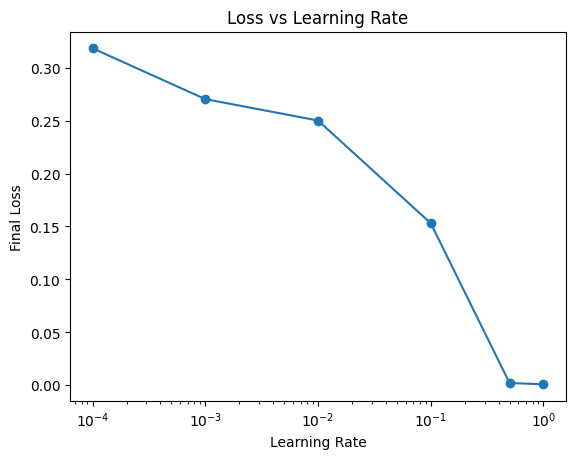

In [ ]:
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5, 1]
final_losses = []

for lr in learning_rates:
    loss = train_mlp(lr)
    final_losses.append(loss)

plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Loss vs Learning Rate")
plt.xscale("log")
plt.show()

Batch Gradient Descent (BGD)

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    learning_rate_init=0.01,
    max_iter=500,
    solver='sgd',
    batch_size=200,
    momentum=0.0,
    random_state=1,
    verbose=True
)

mlp.fit(X, y.ravel())

Iteration 1, loss = 0.74578547
Iteration 2, loss = 0.74518115
Iteration 3, loss = 0.74458467
Iteration 4, loss = 0.74399592
Iteration 5, loss = 0.74341480
Iteration 6, loss = 0.74284121
Iteration 7, loss = 0.74227505
Iteration 8, loss = 0.74171620
Iteration 9, loss = 0.74116458
Iteration 10, loss = 0.74062008
Iteration 11, loss = 0.74008260
Iteration 12, loss = 0.73955205
Iteration 13, loss = 0.73902833
Iteration 14, loss = 0.73851134
Iteration 15, loss = 0.73800101
Iteration 16, loss = 0.73749722
Iteration 17, loss = 0.73699990
Iteration 18, loss = 0.73650894
Iteration 19, loss = 0.73602427
Iteration 20, loss = 0.73555019
Iteration 21, loss = 0.73511371
Iteration 22, loss = 0.73468329
Iteration 23, loss = 0.73425883
Iteration 24, loss = 0.73384024
Iteration 25, loss = 0.73342745
Iteration 26, loss = 0.73302037
Iteration 27, loss = 0.73261892
Iteration 28, loss = 0.73222301
Iteration 29, loss = 0.73183256
Iteration 30, loss = 0.73144750
Iteration 31, loss = 0.73106775
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:609: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


MLPClassifier(batch_size=200, hidden_layer_sizes=(10,), learning_rate_init=0.01,
              max_iter=500, momentum=0.0, random_state=1, solver='sgd',
              verbose=True)

Perceptron Implementation

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

for lr in [0.0001, 0.001, 0.01, 0.1, 1]:
    clf = Perceptron(
        eta0=lr,
        max_iter=1000,
        tol=1e-3,
        penalty=None,
        random_state=42
    )
    clf.fit(X_train, y_train)
    print("LR:", lr, "Accuracy:", clf.score(X_test, y_test))

LR: 0.0001 Accuracy: 0.8888888888888888
LR: 0.001 Accuracy: 0.8888888888888888
LR: 0.01 Accuracy: 0.8888888888888888
LR: 0.1 Accuracy: 0.8888888888888888
LR: 1 Accuracy: 0.8888888888888888


MLP on MNIST

In [ ]:
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow.keras import models, layers

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=15, batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8776 - loss: 0.4257
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9725 - loss: 0.0935
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9828 - loss: 0.0557
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9870 - loss: 0.0403
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9912 - loss: 0.0288
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9925 - loss: 0.0225
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9933 - loss: 0.0194
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9951 - loss: 0.0165
Epoch 9/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9943 - loss: 0.0166
Epoch 10/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9958 - loss: 0.0128
Epoch 11/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9952 - loss: 0.0155
Epoch 12/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/ste

Optimal Architecture

In [ ]:
model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=15, batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8559 - loss: 0.4626
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9588 - loss: 0.1332
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9727 - loss: 0.0892
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9761 - loss: 0.0729
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9801 - loss: 0.0632
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9827 - loss: 0.0563
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9850 - loss: 0.0469
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9845 - loss: 0.0449
Epoch 9/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9868 - loss: 0.0423
Epoch 10/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9867 - loss: 0.0401
Epoch 11/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9885 - loss: 0.0355
Epoch 12/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/ste

#Week 4

In [ ]:
#USING OPTIMIZATION ALGO
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt

y = np.array([[0, 1, 1, 0]]).T

X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model = Sequential()
model.add(Dense(16, input_dim=2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='mean_squared_error',
              optimizer='adam',
              metrics=['binary_accuracy', 'mean_squared_error'])

history = model.fit(X, y, epochs=1000, verbose=0)

errors = history.history['loss']

df2 = pd.DataFrame({"errors":errors, "time-step": np.arange(0, len(errors))})

alt.Chart(df2).mark_line().encode(x="time-step", y="errors").properties(title='Chart 3')

y_pred = model.predict(X).round()
num_correct_predictions = (y_pred == y).sum()
accuracy = (num_correct_predictions / y.shape[0]) * 100
print('Multi-layer perceptron accuracy: %.2f%%' % accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Multi-layer perceptron accuracy: 100.00%


In [ ]:
#USING SGD OPTIMIZATION ALGO
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import altair as alt

y = np.array([[0, 1, 1, 0]]).T

X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model = Sequential()
model.add(Dense(16, input_dim=2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='mean_squared_error',
              optimizer=SGD(),
              metrics=['binary_accuracy', 'mean_squared_error'])

history = model.fit(X, y, epochs=1000, verbose=0)

errors = history.history['loss']

df2 = pd.DataFrame({"errors":errors, "time-step": np.arange(0, len(errors))})

alt.Chart(df2).mark_line().encode(x="time-step", y="errors").properties(title='Chart 3')

y_pred = model.predict(X).round()
num_correct_predictions = (y_pred == y).sum()
accuracy = (num_correct_predictions / y.shape[0]) * 100
print('Multi-layer perceptron accuracy: %.2f%%' % accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Multi-layer perceptron accuracy: 50.00%


In [ ]:
# Using MGD (Momentum Gradient Descent) Optimizer
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt
from tensorflow.keras.optimizers import SGD

# expected values
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model_mgd = Sequential()
model_mgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_mgd.add(Dense(1, activation='sigmoid'))

model_mgd.compile(loss='mean_squared_error',
                  optimizer=SGD(momentum=0.1),
                  metrics=['binary_accuracy', 'mean_squared_error'])

history_mgd = model_mgd.fit(X, y, epochs=1000, verbose=0)

errors_mgd = history_mgd.history['loss']

df_mgd = pd.DataFrame({"errors": errors_mgd, "time-step": np.arange(0, len(errors_mgd))})

alt.Chart(df_mgd).mark_line().encode(x="time-step", y="errors").properties(title='MGD Optimizer - Loss Curve')

y_pred_mgd = model_mgd.predict(X).round()
num_correct_predictions_mgd = (y_pred_mgd == y).sum()
accuracy_mgd = (num_correct_predictions_mgd / y.shape[0]) * 100
print('MGD Optimizer accuracy: %.2f%%' % accuracy_mgd)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
MGD Optimizer accuracy: 50.00%


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
import altair as alt

# expected values
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model_mgd = Sequential()
model_mgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_mgd.add(Dense(1, activation='sigmoid'))

model_mgd.compile(
    loss='mean_squared_error',
    optimizer=SGD(momentum=0.1),
    metrics=['binary_accuracy', 'mean_squared_error']
)

# Early stopping callback
early_stop = EarlyStopping(
    monitor='loss',
    patience=20,
    restore_best_weights=True
)

history_mgd = model_mgd.fit(
    X,
    y,
    epochs=1000,
    callbacks=[early_stop],
    verbose=0
)

errors_mgd = history_mgd.history['loss']

df_mgd = pd.DataFrame({
    "errors": errors_mgd,
    "time-step": np.arange(len(errors_mgd))
})

alt.Chart(df_mgd).mark_line().encode(
    x="time-step",
    y="errors"
).properties(title='MGD Optimizer - Loss Curve (Early Stopping)')

# Evaluate
y_pred_mgd = model_mgd.predict(X).round()
num_correct_predictions_mgd = (y_pred_mgd == y).sum()
accuracy_mgd = (num_correct_predictions_mgd / y.shape[0]) * 100

print(f"MGD Optimizer accuracy: {accuracy_mgd:.2f}%")
print(f"Training stopped at epoch: {len(errors_mgd)}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
MGD Optimizer accuracy: 75.00%
Training stopped at epoch: 1000


In [ ]:
import numpy as np
import pandas as pd
import altair as alt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# expected values
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

# 🔁 Learning rate schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.5,   # HIGH at start
    decay_steps=100,             # how fast it decays
    decay_rate=0.9,              # decay factor
    staircase=False              # smooth decay
)

optimizer = SGD(
    learning_rate=lr_schedule,
    momentum=0.1
)

model_mgd = Sequential()
model_mgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_mgd.add(Dense(1, activation='sigmoid'))

model_mgd.compile(
    loss='mean_squared_error',
    optimizer=optimizer,
    metrics=['binary_accuracy', 'mean_squared_error']
)

early_stop = EarlyStopping(
    monitor='loss',
    patience=20,
    restore_best_weights=True
)

history_mgd = model_mgd.fit(
    X,
    y,
    epochs=1000,
    callbacks=[early_stop],
    verbose=0
)

errors_mgd = history_mgd.history['loss']

df_mgd = pd.DataFrame({
    "errors": errors_mgd,
    "time-step": np.arange(len(errors_mgd))
})

alt.Chart(df_mgd).mark_line().encode(
    x="time-step",
    y="errors"
).properties(title='MGD Optimizer - Dynamic LR + Early Stopping')

# Evaluate
y_pred_mgd = model_mgd.predict(X).round()
accuracy_mgd = (y_pred_mgd == y).mean() * 100

print(f"MGD Optimizer accuracy: {accuracy_mgd:.2f}%")
print(f"Training stopped at epoch: {len(errors_mgd)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
MGD Optimizer accuracy: 50.00%
Training stopped at epoch: 1000


In [ ]:
import numpy as np
import pandas as pd
import altair as alt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler

def step_lr(epoch, lr):
    if epoch < 100:
        return 0.5
    elif epoch < 200:
        return 0.2
    elif epoch < 300:
        return 0.1
    elif epoch < 400:
        return 0.05
    else:
        return 0.01

# expected values (XOR)
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

optimizer = SGD(momentum=0.9)

model_mgd = Sequential()
model_mgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_mgd.add(Dense(1, activation='sigmoid'))

model_mgd.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['binary_accuracy']
)

early_stop = EarlyStopping(
    monitor='loss',
    patience=50,
    restore_best_weights=True
)

lr_scheduler = LearningRateScheduler(step_lr)

history_mgd = model_mgd.fit(
    X,
    y,
    epochs=1000,
    callbacks=[lr_scheduler, early_stop],
    verbose=0
)

# Loss curve
errors_mgd = history_mgd.history['loss']

df_mgd = pd.DataFrame({
    "errors": errors_mgd,
    "time-step": np.arange(len(errors_mgd))
})

alt.Chart(df_mgd).mark_line().encode(
    x="time-step",
    y="errors"
).properties(title='MGD Optimizer – Step LR + Early Stopping')

# Evaluate
y_pred_mgd = model_mgd.predict(X).round()
accuracy_mgd = (y_pred_mgd == y).mean() * 100

print(f"MGD Optimizer accuracy: {accuracy_mgd:.2f}%")
print(f"Training stopped at epoch: {len(errors_mgd)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
MGD Optimizer accuracy: 100.00%
Training stopped at epoch: 1000


In [ ]:
import numpy as np
import pandas as pd
import altair as alt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# XOR data
y = np.array([[0, 1, 1, 0]]).T
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

lrs = [0.5, 0.1, 0.05, 0.01]
ms = [0.1, 0.3, 0.7, 0.9]

for lr in lrs:
    for m in ms:
        # Optimizer with current lr and momentum
        optimizer = SGD(learning_rate=lr, momentum=m)

        # Model
        model = Sequential()
        model.add(Dense(16, input_dim=2, activation='sigmoid'))
        model.add(Dense(1, activation='sigmoid'))

        model.compile(
            loss='binary_crossentropy',
            optimizer=optimizer,
            metrics=['binary_accuracy']
        )

        # Train
        history = model.fit(X, y, epochs=500, verbose=0)

        # Evaluate
        y_pred = model.predict(X).round()
        accuracy = (y_pred == y).mean() * 100

        print("Accuracy\tLearning Rate\tMomentum")
        print(f"{accuracy:.2f}\t\t{lr}\t\t{m}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
Accuracy	Learning Rate	Momentum
75.00		0.5		0.1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
Accuracy	Learning Rate	Momentum
75.00		0.5		0.3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Accuracy	Learning Rate	Momentum
100.00		0.5		0.7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Accuracy	Learning Rate	Momentum
100.00		0.5		0.9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Accuracy	Learning Rate	Momentum
50.00		0.1		0.1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Accuracy	Learning Rate	Momentum
50.00		0.1		0.3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
Accuracy	Learning Rate	Momentum
50.00		0.1		0.7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Accuracy	Learning Rate	Momentum
100.00		0.1		0.9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Accuracy	Learning Rate	Momentum
50.00		0.05		0.1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Accuracy	Learning Rate	Momentum
50.00		0.05		0.3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Accuracy	Learning Rate	Momentum
50.00		0.05		0.7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/ste

#Week 4

Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adadelta, Adam

Create XOR Dataset

In [ ]:
# XOR Data
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=np.float32)

y = np.array([[0],[1],[1],[0]], dtype=np.float32)

Define MLP Model

In [ ]:
def create_xor_model():
    model = Sequential([
        Dense(8, activation='tanh', input_shape=(2,)),
        Dense(1, activation='sigmoid')
    ])
    return model

Train & Record Results Function

In [ ]:
def train_optimizer(optimizer, name, batch_size):

    model = create_xor_model()

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X, y,
        epochs=500,
        batch_size=batch_size,
        verbose=0
    )

    losses = history.history['loss']

    y_pred = (model.predict(X) > 0.5).astype(int)
    accuracy = (y_pred == y).mean() * 100

    print(f"{name}")
    print("Accuracy: %.2f%%" % accuracy)
    print("Predictions:", y_pred.T)
    print("-"*40)

    return losses

Training

In [ ]:
results = {}

# Batch GD
results["BGD"] = train_optimizer(
    SGD(learning_rate=0.1),
    "Batch GD",
    batch_size=4
)

# Stochastic GD
results["SGD"] = train_optimizer(
    SGD(learning_rate=0.1),
    "Stochastic GD",
    batch_size=1
)

# Mini-Batch GD
results["MiniBatch"] = train_optimizer(
    SGD(learning_rate=0.1),
    "Mini Batch GD",
    batch_size=2
)

# Momentum
results["Momentum"] = train_optimizer(
    SGD(learning_rate=0.1, momentum=0.9),
    "SGD with Momentum",
    batch_size=1
)

# Nesterov
results["Nesterov"] = train_optimizer(
    SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    "SGD with Nesterov",
    batch_size=1
)

# Adagrad
results["Adagrad"] = train_optimizer(
    Adagrad(learning_rate=0.5),
    "Adagrad",
    batch_size=1
)

# RMSprop
results["RMSprop"] = train_optimizer(
    RMSprop(learning_rate=0.01),
    "RMSprop",
    batch_size=1
)

# Adadelta
results["Adadelta"] = train_optimizer(
    Adadelta(),
    "Adadelta",
    batch_size=1
)

# Adam
results["Adam"] = train_optimizer(
    Adam(learning_rate=0.01),
    "Adam",
    batch_size=1
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Batch GD
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Stochastic GD
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Mini Batch GD
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
SGD with Momentum
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
SGD with Nesterov
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
Adagrad
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
RMSprop
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
Adadelta
Accuracy: 25.00%
Predictions: [[1 0 0 0]]
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Adam
Accuracy: 100.00%
Predictions: [[0 1 1 0]]
----------------------------------------


Plot Loss Curves

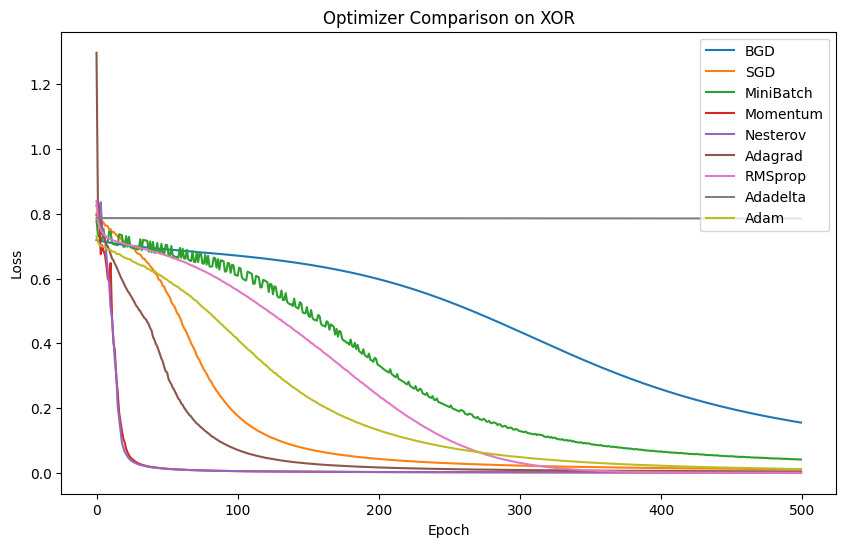

In [ ]:
plt.figure(figsize=(10,6))

for name, loss in results.items():
    plt.plot(loss, label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison on XOR")
plt.legend()
plt.show()

#Week 5

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
422/422 - 10s - 23ms/step - accuracy: 0.8014 - loss: 1.0607 - val_accuracy: 0.8485 - val_loss: 0.7347
Epoch 2/50
422/422 - 4s - 9ms/step - accuracy: 0.8476 - loss: 0.6626 - val_accuracy: 0.8575 - val_loss: 0.5923
Epoch 3/50
422/422 - 1s - 3ms/step - accuracy: 0.8521 - loss: 0.5718 - val_accuracy: 0.8627 - val_loss: 0.5212
Epoch 4/50
422/422 - 1s - 3ms/step - accuracy: 0.8568 - loss: 0.5251 - val_accuracy: 0.8670 - val_loss: 0.4891
Epoch 5/50
422/422 - 1s - 3ms/step - accuracy: 0.8591 - loss: 0.5017 - val_accuracy: 0.8415 - val_loss: 0.5366
Epoch 6/50
422/422 - 2s - 4ms/step - accuracy: 0.8635 - loss: 0.4898 - val_accuracy: 0.8640 - val_loss: 0.4791
Epoch 7/50
422/422 - 1s - 3ms/step - accuracy: 0.8633 - loss: 0.4809 - val_accuracy: 0.8657 - val_loss: 0.4674
Epoch 8/50
422/422 - 1s - 3ms/step - accuracy: 0.8637 - loss: 0.4757 - val_accuracy: 0.8643 - val_loss: 0.4708
Epoch 9/50
422/422 - 1s - 3ms/step - accuracy: 0.8661 - loss: 0.4671 - val_accuracy: 0.8673 - val_loss: 0.4543

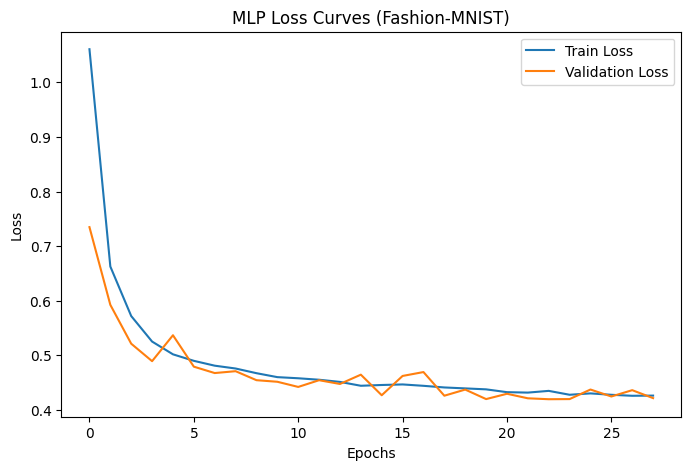

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# =========================
# Load Fashion-MNIST
# =========================
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train = X_train.reshape(-1, 28*28) / 255.0
X_test = X_test.reshape(-1, 28*28) / 255.0

# =========================
# Early stopping
# =========================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# =========================
# Create MLP model
# =========================
def create_mlp_model(dropout_rate=0.0, l2=0.0):
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(28*28,),
                     kernel_regularizer=regularizers.l2(l2)),
        layers.Dropout(dropout_rate),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2)),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# =========================
# Train model with L2 + Dropout
# =========================
model = create_mlp_model(dropout_rate=0.2, l2=0.001)
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=2
)

# =========================
# Evaluate
# =========================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_acc)

# =========================
# Plot loss curves
# =========================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MLP Loss Curves (Fashion-MNIST)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Week 5

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 Reshape to (samples, 28, 28, 1) for augmentation
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 🔹 Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=5,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=False
)

datagen.fit(x_train)

# 🔹 Build Model (with L2 regularization)
def build_l2_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Train using augmented data
history = model_l2.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train) // 32
)

# 🔹 Evaluate model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

Regularization

In [1]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers

# Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize the input data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 FIX: Reshape 28x28 images into 784-length vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Define a simple model with L2 regularization
def build_l2_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu',
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model_l2.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

# Evaluate the model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7310 - loss: 1.4193 - val_accuracy: 0.8130 - val_loss: 0.7485
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8089 - loss: 0.7378 - val_accuracy: 0.8202 - val_loss: 0.6796
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8209 - loss: 0.6699 - val_accuracy: 0.8182 - val_loss: 0.6633
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8214 - loss: 0.6428 - val_accuracy: 0.8237 - val_loss: 0.6342
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8298 - loss: 0.6162 - val_accuracy: 0.8320 - val_loss: 0.5996
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8312 - loss: 0.5963 - val_accuracy: 0.8014 - val_loss: 0.6525
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8368 - loss: 0.5817 - val_accuracy: 0.8437 - val_loss: 0.5637
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8392 - loss: 0.5636 - 

In [2]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers

# Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize the input data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 FIX: Reshape 28x28 images into 784-length vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Define a simple model with L2 regularization
def build_l2_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu',
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l2(0.05)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.05)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model_l2.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

# Evaluate the model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7049 - loss: 2.5602 - val_accuracy: 0.7667 - val_loss: 0.9756
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7638 - loss: 0.9461 - val_accuracy: 0.7533 - val_loss: 0.9452
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7777 - loss: 0.8617 - val_accuracy: 0.7860 - val_loss: 0.8193
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7875 - loss: 0.8125 - val_accuracy: 0.7879 - val_loss: 0.7962
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7918 - loss: 0.7883 - val_accuracy: 0.7972 - val_loss: 0.7561
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7938 - loss: 0.7679 - val_accuracy: 0.7948 - val_loss: 0.7500
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7977 - loss: 0.7441 - val_accuracy: 0.7992 - val_loss: 0.7386
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8008 - loss: 0.7338 -

In [3]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers

# Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize the input data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 FIX: Reshape 28x28 images into 784-length vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Define a simple model with L2 regularization
def build_l2_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu',
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model_l2.fit(
    x_train,
    y_train,
    epochs=25,
    validation_split=0.2,
    batch_size=32
)

# Evaluate the model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7589 - loss: 0.8508 - val_accuracy: 0.8330 - val_loss: 0.5818
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8507 - loss: 0.5264 - val_accuracy: 0.8557 - val_loss: 0.4974
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8608 - loss: 0.4827 - val_accuracy: 0.8486 - val_loss: 0.5036
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8594 - loss: 0.4742 - val_accuracy: 0.8602 - val_loss: 0.4685
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8660 - loss: 0.4565 - val_accuracy: 0.8493 - val_loss: 0.4861
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8701 - loss: 0.4424 - val_accuracy: 0.8679 - val_loss: 0.4450
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8692 - loss: 0.4407 - val_accuracy: 0.8697 - val_loss: 0.4419
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8748 - loss: 0.4288 - 

In [6]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers

# Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize the input data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 FIX: Reshape 28x28 images into 784-length vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Define a simple model with L2 regularization
def build_l2_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu',
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model_l2.fit(
    x_train,
    y_train,
    epochs=25,
    validation_split=0.2,
    batch_size=64
)

# Evaluate the model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.7325 - loss: 0.9322 - val_accuracy: 0.8399 - val_loss: 0.5826
Epoch 2/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8499 - loss: 0.5504 - val_accuracy: 0.8517 - val_loss: 0.5186
Epoch 3/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8576 - loss: 0.5123 - val_accuracy: 0.8608 - val_loss: 0.4905
Epoch 4/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8649 - loss: 0.4760 - val_accuracy: 0.8588 - val_loss: 0.4851
Epoch 5/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8694 - loss: 0.4592 - val_accuracy: 0.8666 - val_loss: 0.4596
Epoch 6/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8710 - loss: 0.4490 - val_accuracy: 0.8643 - val_loss: 0.4603
Epoch 7/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8732 - loss: 0.4385 - val_accuracy: 0.8611 - val_loss: 0.4566
Epoch 8/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8755 - loss: 0.4241 - val_accuracy: 

In [10]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers

# Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize the input data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 FIX: Reshape 28x28 images into 784-length vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Define a simple model with L2 regularization
def build_l2_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu',
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(64, activation='tanh',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model_l2.fit(
    x_train,
    y_train,
    epochs=25,
    validation_split=0.2,
    batch_size=64
)

# Evaluate the model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7474 - loss: 0.9094 - val_accuracy: 0.8517 - val_loss: 0.5425
Epoch 2/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8492 - loss: 0.5420 - val_accuracy: 0.8513 - val_loss: 0.5185
Epoch 3/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8624 - loss: 0.4887 - val_accuracy: 0.8562 - val_loss: 0.4896
Epoch 4/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8666 - loss: 0.4632 - val_accuracy: 0.8651 - val_loss: 0.4687
Epoch 5/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8665 - loss: 0.4548 - val_accuracy: 0.8718 - val_loss: 0.4412
Epoch 6/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8723 - loss: 0.4358 - val_accuracy: 0.8644 - val_loss: 0.4566
Epoch 7/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8721 - loss: 0.4320 - val_accuracy: 0.8718 - val_loss: 0.4386
Epoch 8/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8773 - loss: 0.4206 - val_accuracy: 0.

In [8]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers

# Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize the input data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 FIX: Reshape 28x28 images into 784-length vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Define a simple model with L2 regularization
def build_l2_model():
    model = models.Sequential([
        layers.Dense(64,
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.LeakyReLU(alpha=0.01),

        layers.Dense(64,
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.LeakyReLU(alpha=0.01),

        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model_l2.fit(
    x_train,
    y_train,
    epochs=25,
    validation_split=0.2,
    batch_size=64
)

# Evaluate the model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7460 - loss: 0.9122 - val_accuracy: 0.8488 - val_loss: 0.5560
Epoch 2/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8504 - loss: 0.5492 - val_accuracy: 0.8497 - val_loss: 0.5269
Epoch 3/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8581 - loss: 0.5052 - val_accuracy: 0.8577 - val_loss: 0.4963
Epoch 4/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8654 - loss: 0.4766 - val_accuracy: 0.8627 - val_loss: 0.4833
Epoch 5/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8688 - loss: 0.4567 - val_accuracy: 0.8668 - val_loss: 0.4659
Epoch 6/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8717 - loss: 0.4461 - val_accuracy: 0.8665 - val_loss: 0.4610
Epoch 7/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8717 - loss: 0.4357 - val_accuracy: 0.8727 - val_loss: 0.4430
Epoch 8/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8732 - loss: 0.4310 - val_accuracy: 0.

In [4]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers

# Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize the input data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 FIX: Reshape 28x28 images into 784-length vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Define a simple model with L1 regularization
def build_l1_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu',
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l1(0.001)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l1(0.001)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l1 = build_l1_model()

model_l1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model_l1.fit(
    x_train,
    y_train,
    epochs=25,
    validation_split=0.2,
    batch_size=32
)

# Evaluate the model
test_loss, test_acc = model_l1.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7316 - loss: 1.8187 - val_accuracy: 0.8045 - val_loss: 0.9101
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8146 - loss: 0.8440 - val_accuracy: 0.7977 - val_loss: 0.8120
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8210 - loss: 0.7436 - val_accuracy: 0.8274 - val_loss: 0.7042
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8295 - loss: 0.6917 - val_accuracy: 0.8315 - val_loss: 0.6679
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8316 - loss: 0.6718 - val_accuracy: 0.8350 - val_loss: 0.6452
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8372 - loss: 0.6436 - val_accuracy: 0.8442 - val_loss: 0.6124
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8329 - loss: 0.6382 - val_accuracy: 0.8390 - val_loss: 0.6298
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8369 - loss: 0.6184 - 

Dataset Augmentation

In [12]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 Reshape to (samples, 28, 28, 1) for augmentation
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 🔹 Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    vertical_flip=False
)

datagen.fit(x_train)

# 🔹 Build Model (with L2 regularization)
def build_l2_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Train using augmented data
history = model_l2.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train) // 32
)

# 🔹 Evaluate model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.6217 - loss: 1.6363 - val_accuracy: 0.7250 - val_loss: 0.8972
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.6970 - loss: 0.9761 - val_accuracy: 0.7454 - val_loss: 0.8366
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.7069 - loss: 0.9155 - val_accuracy: 0.7313 - val_loss: 0.8516
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.7111 - loss: 0.8887 - val_accuracy: 0.7330 - val_loss: 0.8121
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.7219 - loss: 0.8606 - val_accuracy: 0.7497 - val_loss: 0.7746
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.7180 - loss: 0.8487 - val_accuracy: 0.7477 - val_loss: 0.7704
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.7216 - loss: 0.8427 - val_accuracy: 0.7677 - val_loss: 0.7350
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.7246 -

In [13]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 Reshape to (samples, 28, 28, 1) for augmentation
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 🔹 Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=False
)

datagen.fit(x_train)

# 🔹 Build Model (with L2 regularization)
def build_l2_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Train using augmented data
history = model_l2.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train) // 32
)

# 🔹 Evaluate model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.6849 - loss: 1.5005 - val_accuracy: 0.7748 - val_loss: 0.8139
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.7566 - loss: 0.8440 - val_accuracy: 0.7697 - val_loss: 0.7575
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.7662 - loss: 0.7865 - val_accuracy: 0.7907 - val_loss: 0.7229
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.7762 - loss: 0.7440 - val_accuracy: 0.7940 - val_loss: 0.6918
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.7810 - loss: 0.7266 - val_accuracy: 0.8018 - val_loss: 0.6764
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.7845 - loss: 0.7095 - val_accuracy: 0.8014 - val_loss: 0.6557
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.7874 - loss: 0.6972 - val_accuracy: 0.7991 - val_loss: 0.6622
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.7866 - loss: 0.68

In [15]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 Reshape to (samples, 28, 28, 1) for augmentation
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 🔹 Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=5,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=False
)

datagen.fit(x_train)

# 🔹 Build Model (with L2 regularization)
def build_l2_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Train using augmented data
history = model_l2.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train) // 32
)

# 🔹 Evaluate model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.6983 - loss: 1.5015 - val_accuracy: 0.7750 - val_loss: 0.8159
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - accuracy: 0.7697 - loss: 0.8276 - val_accuracy: 0.7857 - val_loss: 0.7522
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.7788 - loss: 0.7614 - val_accuracy: 0.7987 - val_loss: 0.6948
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.7844 - loss: 0.7292 - val_accuracy: 0.8104 - val_loss: 0.6692
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7867 - loss: 0.7092 - val_accuracy: 0.8023 - val_loss: 0.6575
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.7951 - loss: 0.6880 - val_accuracy: 0.8118 - val_loss: 0.6391
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7958 - loss: 0.6785 - val_accuracy: 0.7931 - val_loss: 0.6781
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7994 -

In [17]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 Reshape to (samples, 28, 28, 1) for augmentation
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 🔹 Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=5,
    zoom_range=0,
    horizontal_flip=True
)

datagen.fit(x_train)

# 🔹 Build Model (with L2 regularization)
def build_l2_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Train using augmented data
history = model_l2.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train) // 32
)

# 🔹 Evaluate model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.7099 - loss: 1.4482 - val_accuracy: 0.7903 - val_loss: 0.7938
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.7926 - loss: 0.7789 - val_accuracy: 0.8036 - val_loss: 0.7108
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.7951 - loss: 0.7286 - val_accuracy: 0.7924 - val_loss: 0.7178
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - accuracy: 0.8067 - loss: 0.6918 - val_accuracy: 0.7758 - val_loss: 0.7233
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8092 - loss: 0.6692 - val_accuracy: 0.8202 - val_loss: 0.6416
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8167 - loss: 0.6418 - val_accuracy: 0.8063 - val_loss: 0.6561
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - accuracy: 0.8158 - loss: 0.6363 - val_accuracy: 0.8228 - val_loss: 0.6156
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8178 - loss: 0.62

In [19]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 Reshape to (samples, 28, 28, 1) for augmentation
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 🔹 Build Model (with L2 regularization)
def build_l2_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Train using augmented data
history = model_l2.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train) // 32
)

# 🔹 Evaluate model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 36ms/step - accuracy: 0.7303 - loss: 1.4280 - val_accuracy: 0.7966 - val_loss: 0.7741
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8035 - loss: 0.7553 - val_accuracy: 0.8126 - val_loss: 0.7187
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8086 - loss: 0.7015 - val_accuracy: 0.8098 - val_loss: 0.6738
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8134 - loss: 0.6683 - val_accuracy: 0.8199 - val_loss: 0.6423
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8225 - loss: 0.6370 - val_accuracy: 0.8210 - val_loss: 0.6383
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8223 - loss: 0.6294 - val_accuracy: 0.8178 - val_loss: 0.6374
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8311 - loss: 0.6036 - val_accuracy: 0.8168 - val_loss: 0.6217
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8304 - loss: 0.59

Early Stopping

In [21]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape to 784 vector
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build simple model (NO L2 regularization)
def build_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Early Stopping
earlystop = EarlyStopping(
    monitor='val_accuracy',   # Monitor validation accuracy
    patience=3,               # Stop if no improvement after 3 epochs
    restore_best_weights=True # Restore best model weights
)

epochs = 20  # change this value and check
batch_size = 256   # change this value and check

# Train model with Early Stopping
history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[earlystop]
)

# Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6556 - loss: 1.0583 - val_accuracy: 0.8320 - val_loss: 0.4843
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8406 - loss: 0.4644 - val_accuracy: 0.8515 - val_loss: 0.4250
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8587 - loss: 0.4013 - val_accuracy: 0.8608 - val_loss: 0.3899
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8704 - loss: 0.3713 - val_accuracy: 0.8564 - val_loss: 0.4008
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8710 - loss: 0.3650 - val_accuracy: 0.8702 - val_loss: 0.3684
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8799 - loss: 0.3375 - val_accuracy: 0.8760 - val_loss: 0.3534
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8867 - loss: 0.3158 - val_accuracy: 0.8751 - val_loss: 0.3567
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8865 - loss: 0.3119 - val_accuracy: 0

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape to 784 vector
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build simple model (NO L2 regularization)
def build_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Early Stopping
earlystop = EarlyStopping(
    monitor='val_accuracy',   # Monitor validation accuracy
    patience=3,               # Stop if no improvement after 3 epochs
    restore_best_weights=True # Restore best model weights
)

epochs = 20  # change this value and check
batch_size = 256   # change this value and check

# Train model with Early Stopping
history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[earlystop]
)

# Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")